In [101]:
import os
import time
import math

import pandas as pd
import numpy as np
from scipy import stats as st
from tqdm import tqdm

import plotly.graph_objects as go
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

import sys
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')

from src import MMSEMetropolisHastingsEstimator, MAPGradientAscentEstimator, InstantaneousMixtureModel, PosteriorContourLines, ContourLineGraphPlotter, MCMCGraphPlotter, MAPGradientAscentGraphPlotter, ExponentialPrior, LogisticSource, BayesianEstimators, TriangularSource, ExperimentExecutor

print(os.cpu_count())

np.random.seed(2000)

8


# 1. Logistic function

In [102]:
N_SAMPLES = 100000

# Initialize the standard generator
rng = np.random.default_rng()

# Generate the data
samples = rng.normal(
    loc=0.0,
    scale=1.0,
    size=N_SAMPLES
)


In [103]:
def logistic_times(
    get_logistic_fn,
    samples,
):
    time_logs = pd.DataFrame()
    logistic_fn = get_logistic_fn()
    for k, s in enumerate(samples):
        start = time.perf_counter_ns()
        post = logistic_fn(s)
        end = time.perf_counter_ns()

        time_logs = pd.concat(
            [
                time_logs,
                pd.DataFrame(
                    index=[k],
                    data = {
                        's': [s],
                        'start_time': [start],
                        'end_time': [end],
                        'elapsed_time': [end-start]
                    }
                )
            ],
            axis=0
        )

    time_logs['elapsed_time_microsecs'] = time_logs['elapsed_time']/1000

    plot_df = time_logs[
        time_logs['elapsed_time']<time_logs['elapsed_time'].quantile(0.99)
    ]


    fig = plt.figure(figsize=(20,7))
    h = plt.hist(
        x=plot_df['elapsed_time_microsecs'],
        bins='fd'
    )
    
    return time_logs

## 1.1 Função original

In [104]:
def get_logistic_original():
    def __logistic_distribution(
        x
    ):
        """
            This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
        """
        mu=0
        sigma=1
        return np.exp(
            -(x-mu)/sigma
        )/(
            sigma*np.square(
                1 + np.exp(-(x-mu)/sigma)
            )
        )
        
    return lambda x: __logistic_distribution(x=x)

count    100000.000000
mean          2.121682
std           0.475624
min           1.833000
25%           2.042000
50%           2.084000
75%           2.125000
max          80.458000
Name: elapsed_time_microsecs, dtype: float64

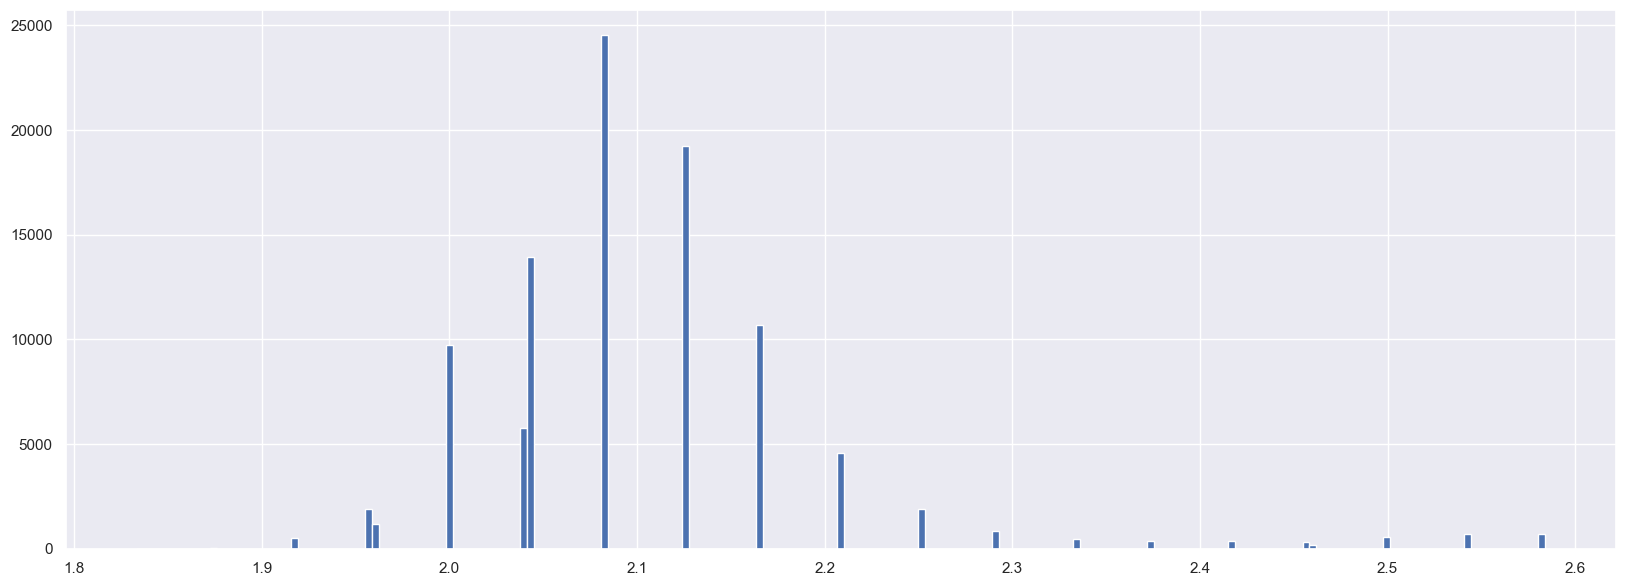

In [105]:
time_logs_original = logistic_times(
    get_logistic_fn=get_logistic_original,
    samples=[0]*N_SAMPLES
)
time_logs_original.elapsed_time_microsecs.describe()

count    100000.000000
mean          2.250687
std           0.323990
min           2.000000
25%           2.208000
50%           2.209000
75%           2.291000
max          33.250000
Name: elapsed_time_microsecs, dtype: float64

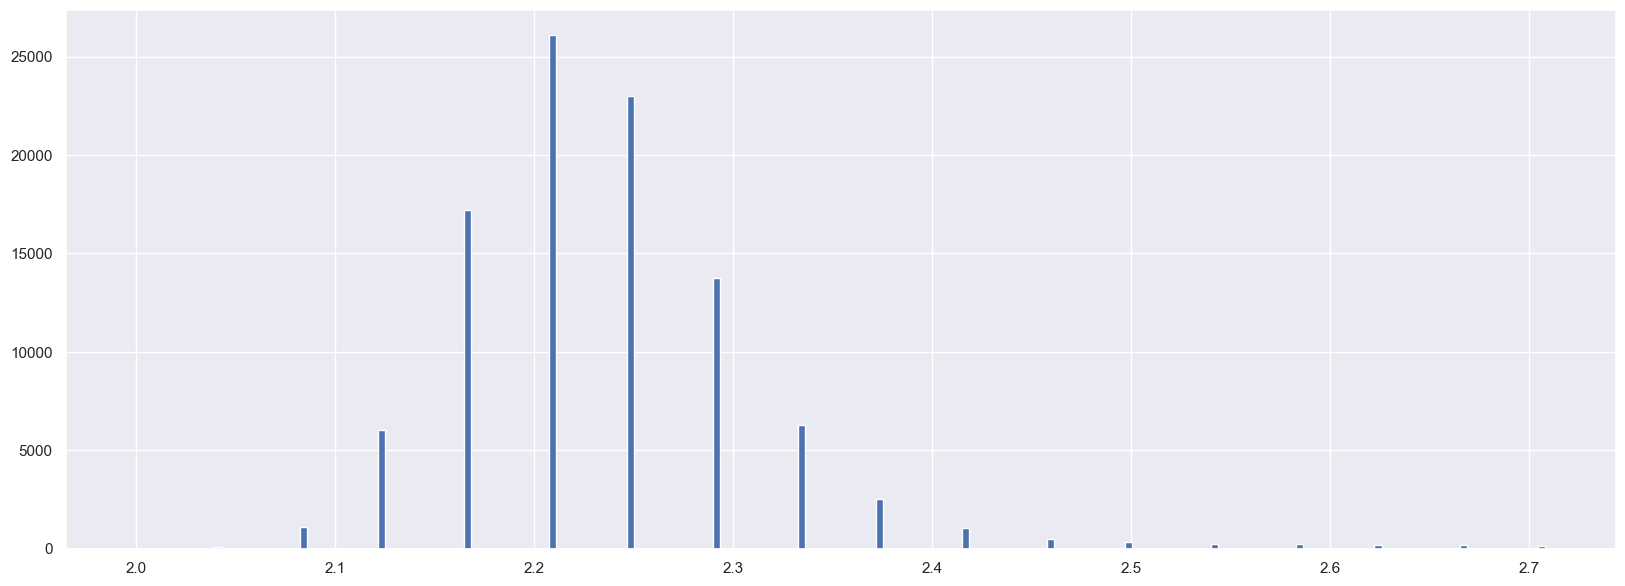

In [106]:
time_logs_original = logistic_times(
    get_logistic_fn=get_logistic_original,
    samples=samples
)
time_logs_original.elapsed_time_microsecs.describe()

## 1.2 Reaproveitamento do argumento exponencial

In [107]:
def get_logistic_reuse_exp():
    def __logistic_distribution(
        x
    ):
        """
            This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
        """
        mu=0
        sigma=1
        arg = np.exp(
            -(x-mu)/sigma
        )
        return arg/(
            sigma*np.square(
                1 + arg
            )
        )
        
    return lambda x: __logistic_distribution(x=x)

count    100000.00000
mean          1.71592
std           0.25714
min           1.50000
25%           1.66600
50%           1.70800
75%           1.75000
max          42.20900
Name: elapsed_time_microsecs, dtype: float64

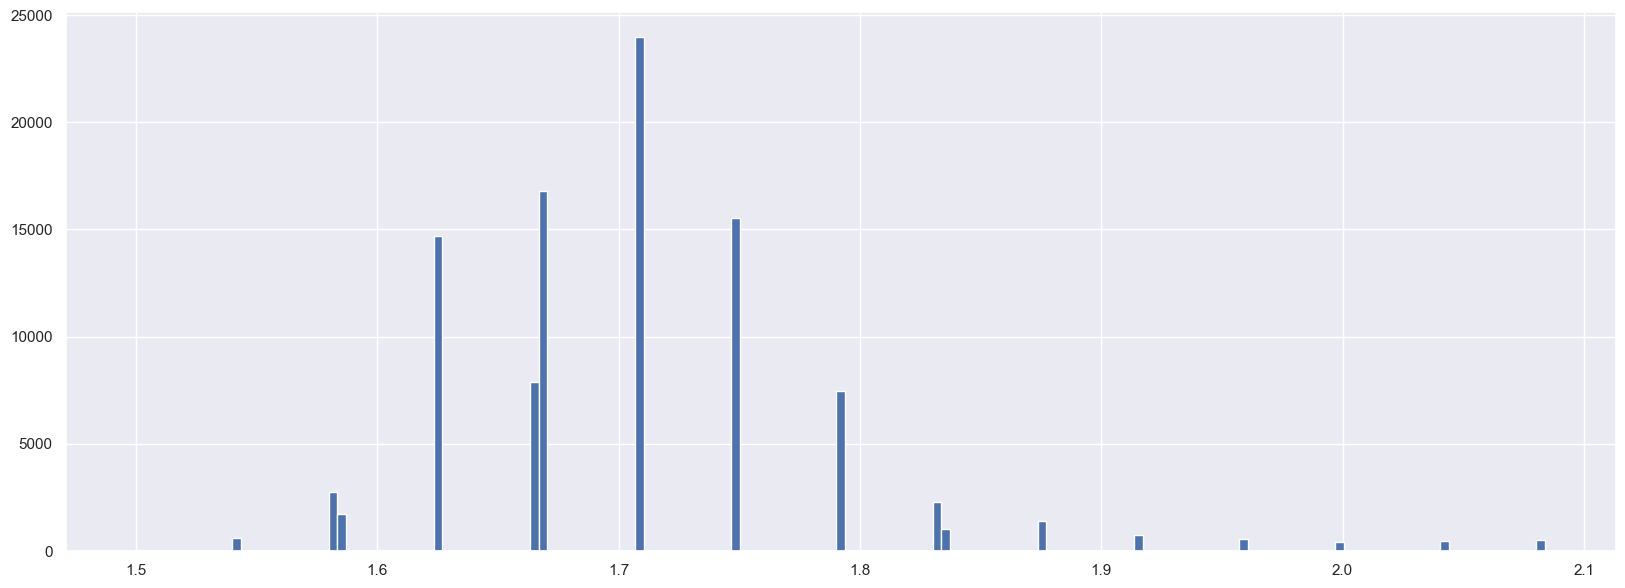

In [108]:
time_logs_reuse_exp = logistic_times(
    get_logistic_fn=get_logistic_reuse_exp,
    samples=[0]*N_SAMPLES
)
time_logs_reuse_exp.elapsed_time_microsecs.describe()

count    100000.000000
mean          1.782408
std           0.358332
min           1.542000
25%           1.709000
50%           1.750000
75%           1.792000
max          36.584000
Name: elapsed_time_microsecs, dtype: float64

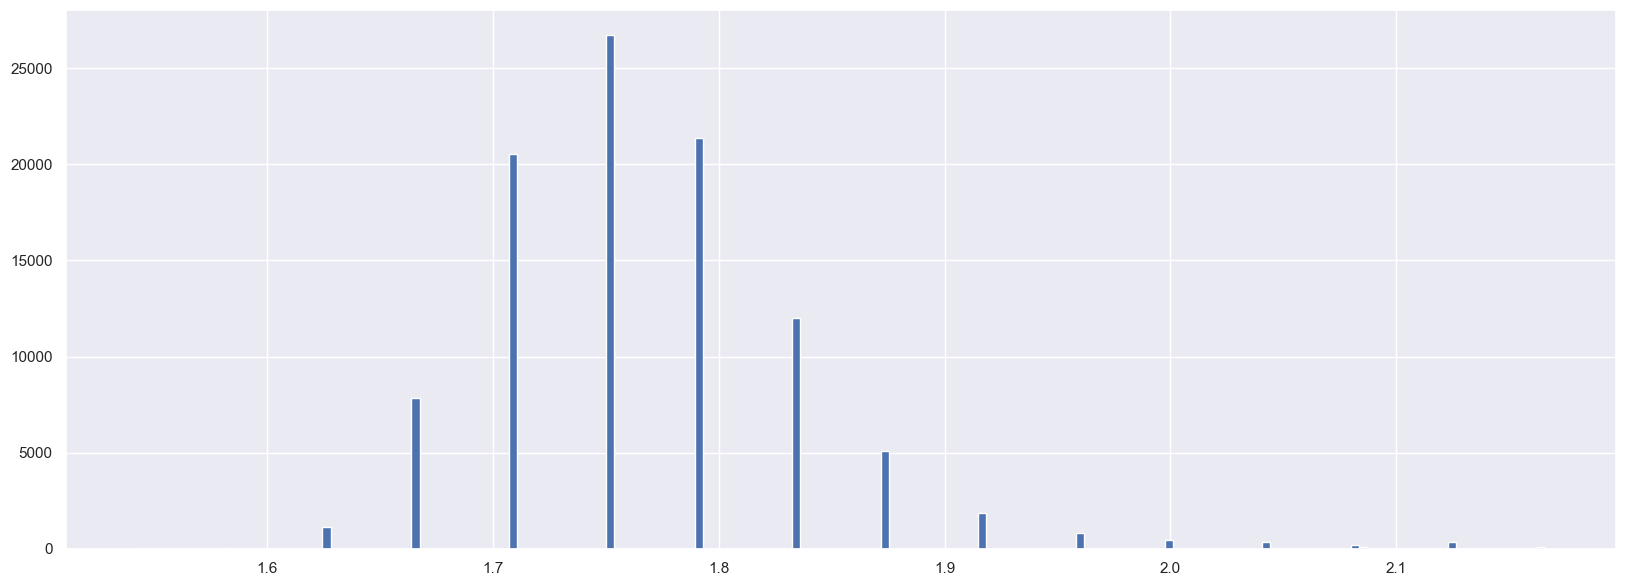

In [109]:
time_logs_reuse_exp = logistic_times(
    get_logistic_fn=get_logistic_reuse_exp,
    samples=samples
)
time_logs_reuse_exp.elapsed_time_microsecs.describe()

## 1.3 Simplificação de operações com mu=0 e sigma=1

In [110]:
def get_logistic_standard():
    def __logistic_distribution(
        x
    ):
        """
            This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
        """
        arg = np.exp(-x)
        return arg/np.square(1+arg)
        
    return lambda x: __logistic_distribution(x=x)

count    100000.000000
mean          1.867892
std           0.339229
min           1.625000
25%           1.792000
50%           1.833000
75%           1.875000
max          31.625000
Name: elapsed_time_microsecs, dtype: float64

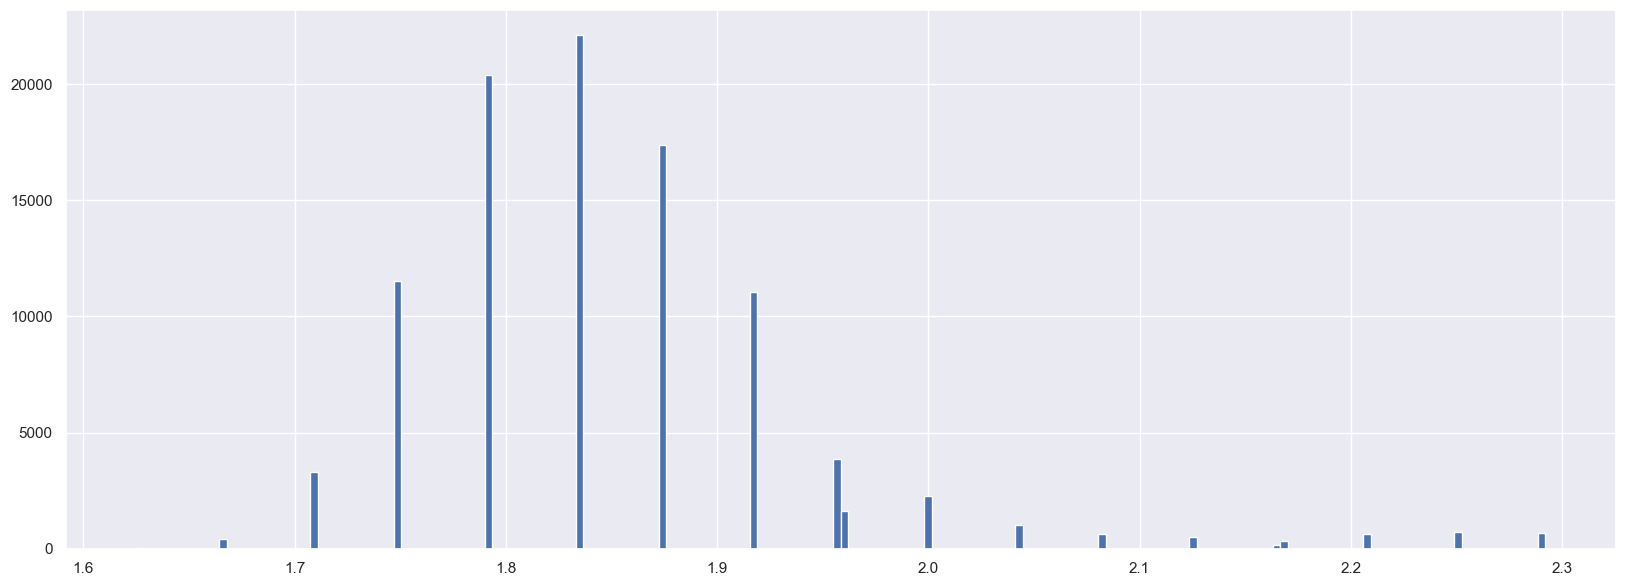

In [111]:
time_logs_standard = logistic_times(
    get_logistic_fn=get_logistic_standard,
    samples=[0]*N_SAMPLES
)
time_logs_standard.elapsed_time_microsecs.describe()

count    100000.000000
mean          1.520172
std           0.363651
min           1.333000
25%           1.458000
50%           1.500000
75%           1.542000
max          43.083000
Name: elapsed_time_microsecs, dtype: float64

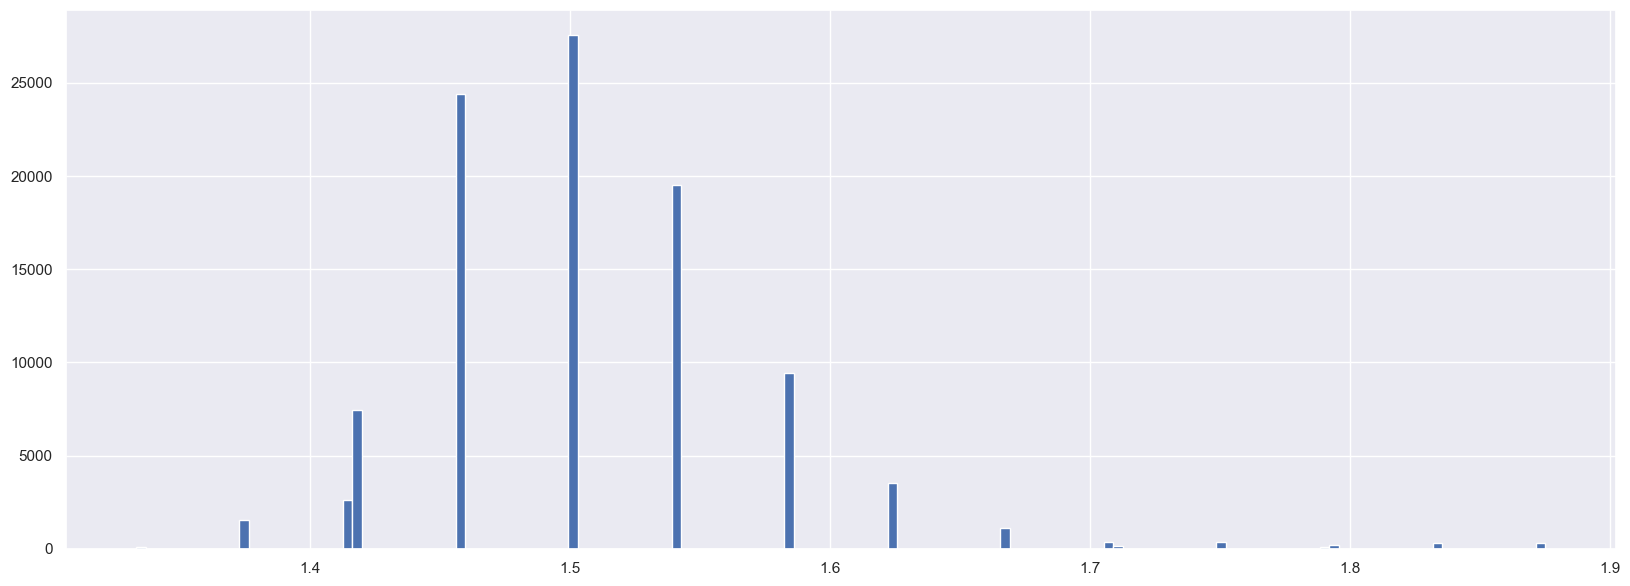

In [112]:
time_logs_standard = logistic_times(
    get_logistic_fn=get_logistic_standard,
    samples=samples
)
time_logs_standard.elapsed_time_microsecs.describe()

## 1.4 Math.exp()

In [113]:
def get_logistic_math():
    def __logistic_distribution(
        x
    ):
        """
            This method takes SCALAR value x and return SCALAR source pdf evaluated at x.
        """
        arg = math.exp(-x)
        return arg/np.square(1+arg)
        
    return lambda x: __logistic_distribution(x=x)

count    100000.000000
mean          1.123367
std           0.274082
min           0.875000
25%           1.083000
50%           1.125000
75%           1.125000
max          30.250000
Name: elapsed_time_microsecs, dtype: float64

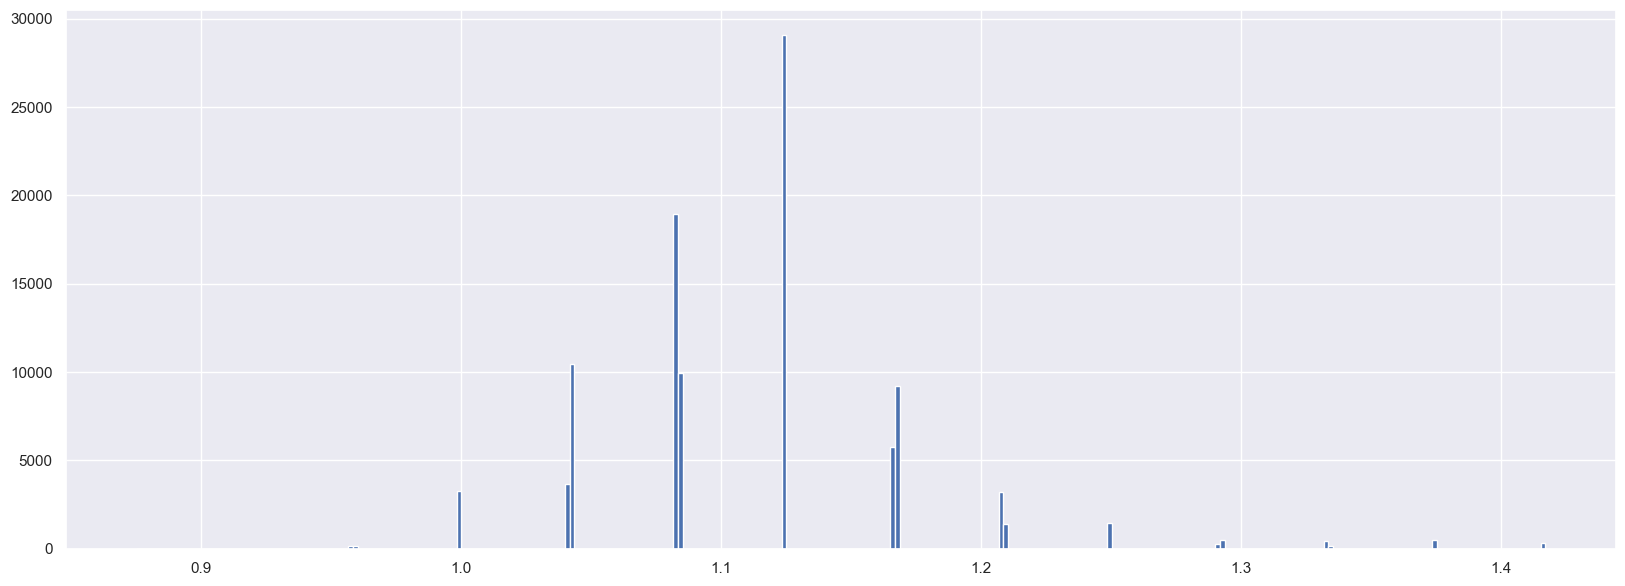

In [114]:
time_logs_math = logistic_times(
    get_logistic_fn=get_logistic_math,
    samples=[0]*N_SAMPLES
)
time_logs_math.elapsed_time_microsecs.describe()

count    100000.000000
mean          1.169444
std           0.253702
min           1.000000
25%           1.125000
50%           1.166000
75%           1.208000
max          41.292000
Name: elapsed_time_microsecs, dtype: float64

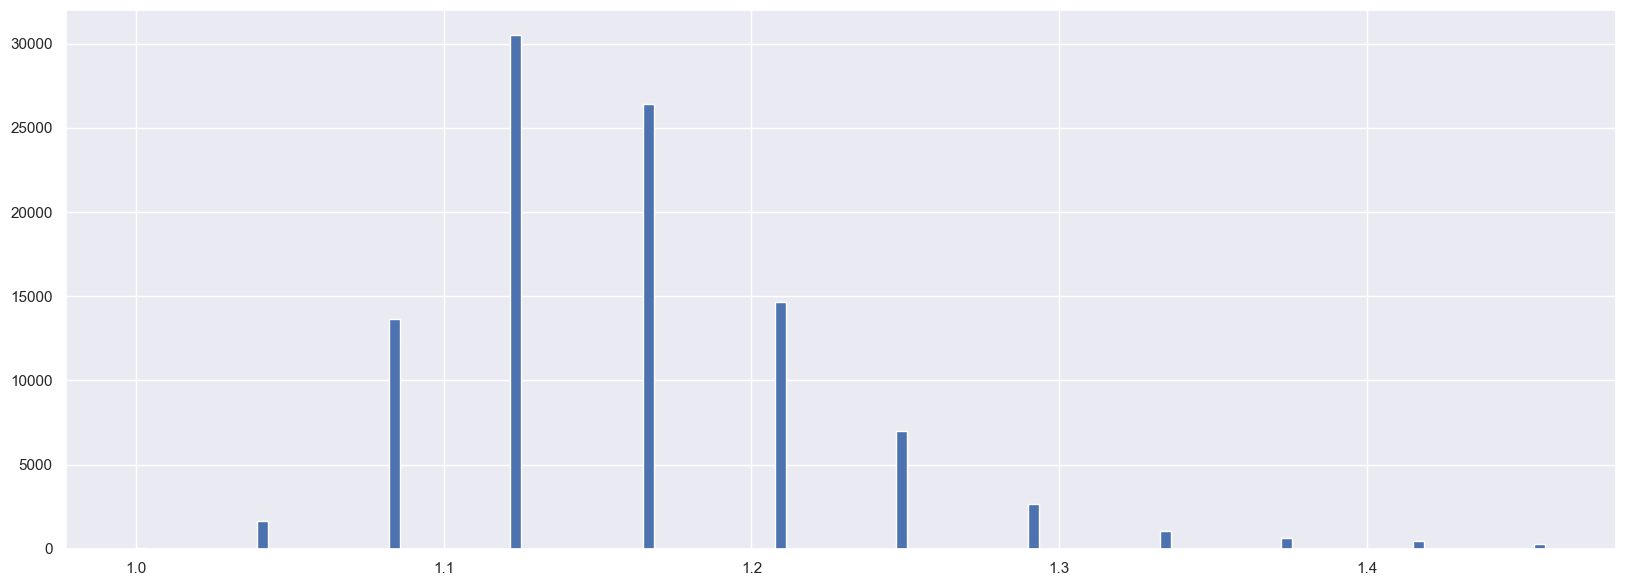

In [115]:
time_logs_math = logistic_times(
    get_logistic_fn=get_logistic_math,
    samples=samples
)
time_logs_math.elapsed_time_microsecs.describe()

# 3. Posterior function

## 3.1. Criação de matrizes aleatórias

####################################################################################################
Max det: 8.036917883083163
Min det: -8.416974864040691
Min abs det: 0.00013994612030763338
####################################################################################################


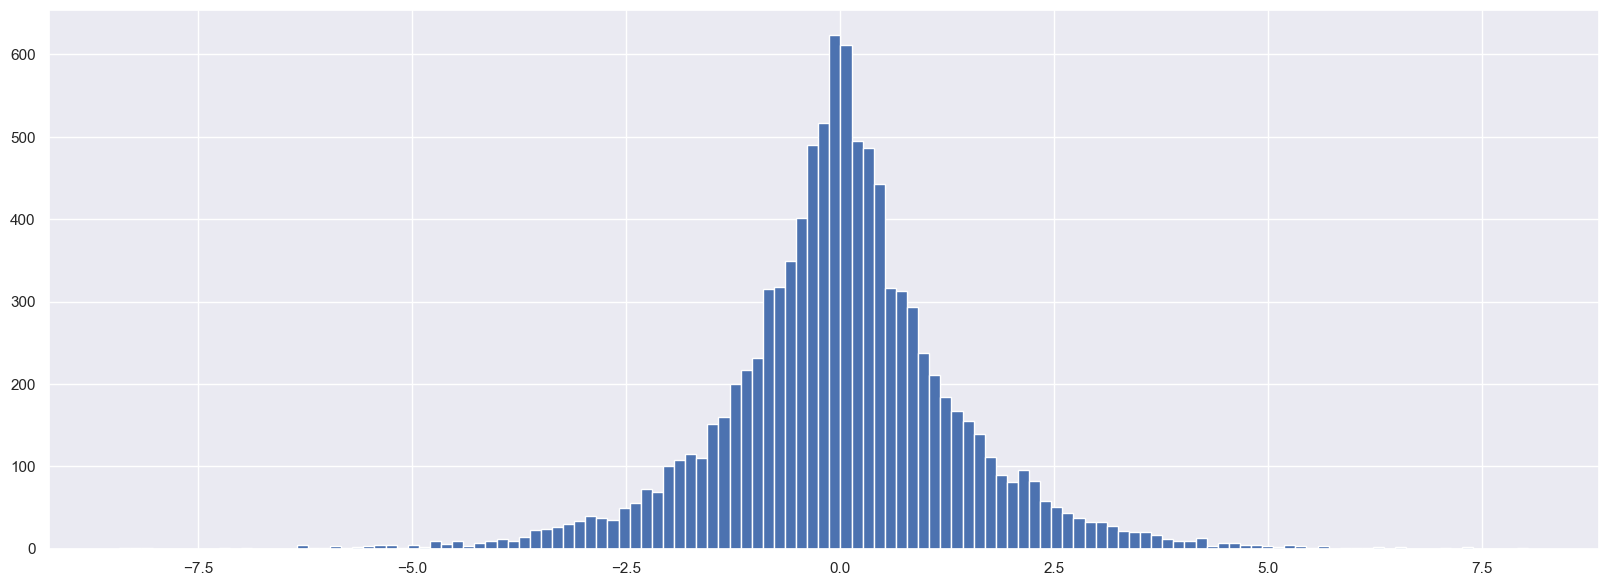

In [116]:
N_MAT = 10000

# Initialize the standard generator
rng = np.random.default_rng()

# Generate the data
samples = rng.normal(loc=0.0, scale=1.0, size=(N_MAT,2,2))

# Get dict with samples data
samples_data = {
    i: {
        'matrix': m,
        'det': np.linalg.det(m)
    } for i, m in enumerate(samples)
}

determinants = [v['det'] for k, v in samples_data.items()]

fig = plt.figure(figsize=(20,7))
h=plt.hist(
    determinants,
    bins='fd'
)

print('#'*100)
print('Max det: {}'.format(np.max(determinants)))
print('Min det: {}'.format(np.min(determinants)))
print('Min abs det: {}'.format(np.min(np.abs(determinants))))
print('#'*100)


In [117]:
# Define mixing matrix
A = np.array([
    [1, 1],
    [-0.5, 0.5]
])

# Define signal for posterior
N=1000
source_pdf = LogisticSource(
    mu=0.0,
    sigma=1.0
)
X = A@source_pdf.get_realization(
    nsources=2,
    nobs=N
)

# Define prior
prior = ExponentialPrior(
    center=np.eye(2),
    std=10
)

In [118]:
def log_posterior_times(
    get_log_posterior_fn,
    X,
    source_pdf_fn,
    prior_pdf_fn,
    samples_data,
):
    time_logs = pd.DataFrame()
    log_posterior_fn = get_log_posterior_fn(
        source_pdf_fn = source_pdf_fn,
        prior_pdf_fn = prior_pdf_fn
    )
    for k, v in samples_data.items():
        B = v['matrix']
        start = time.perf_counter_ns()
        post = log_posterior_fn(
            x=X,
            B=B
        )
        end = time.perf_counter_ns()

        time_logs = pd.concat(
            [
                time_logs,
                pd.DataFrame(
                    index=[k],
                    data = {
                        'B': [B],
                        'B_det': v['det'],
                        'start_time': [start],
                        'end_time': [end],
                        'elapsed_time': [end-start]
                    }
                )
            ],
            axis=0
        )

    time_logs['elapsed_time_microsecs'] = time_logs['elapsed_time']/1000

    plot_df = time_logs[
        time_logs['elapsed_time']<time_logs['elapsed_time'].quantile(0.99)
    ]

    fig = plt.figure(figsize=(20,7))
    h = plt.hist(
        x=plot_df['elapsed_time_microsecs'],
        bins='fd'
    )
    
    return time_logs

In [119]:
def get_log_posterior_fn_original(
    source_pdf_fn,
    prior_pdf_fn
):
    """
        This method returns a method for calculating log-posterior inside MCMC.
    """
    def __log_posterior_fn(
        x,
        B,
        source_pdf_fn,
        prior_pdf_fn
    ):
        NOBS=x.shape[-1]
        
        # Cálculo de posteriori para registros
        posteriori = NOBS*np.log(np.abs(np.linalg.det(B)))
        y=B@x
        for i, j in np.ndindex(x.shape):
            posteriori += np.log(source_pdf_fn(y[i,j]))
        posteriori += np.log(prior_pdf_fn(B))
    
        return posteriori

    return lambda x, B: __log_posterior_fn(
        x=x,
        B=B,
        source_pdf_fn=source_pdf_fn,
        prior_pdf_fn=prior_pdf_fn
    )


count    10000.000000
mean      3888.712293
std        396.236976
min       3705.041000
25%       3812.750000
50%       3853.708000
75%       3901.052250
max      23140.208000
Name: elapsed_time_microsecs, dtype: float64

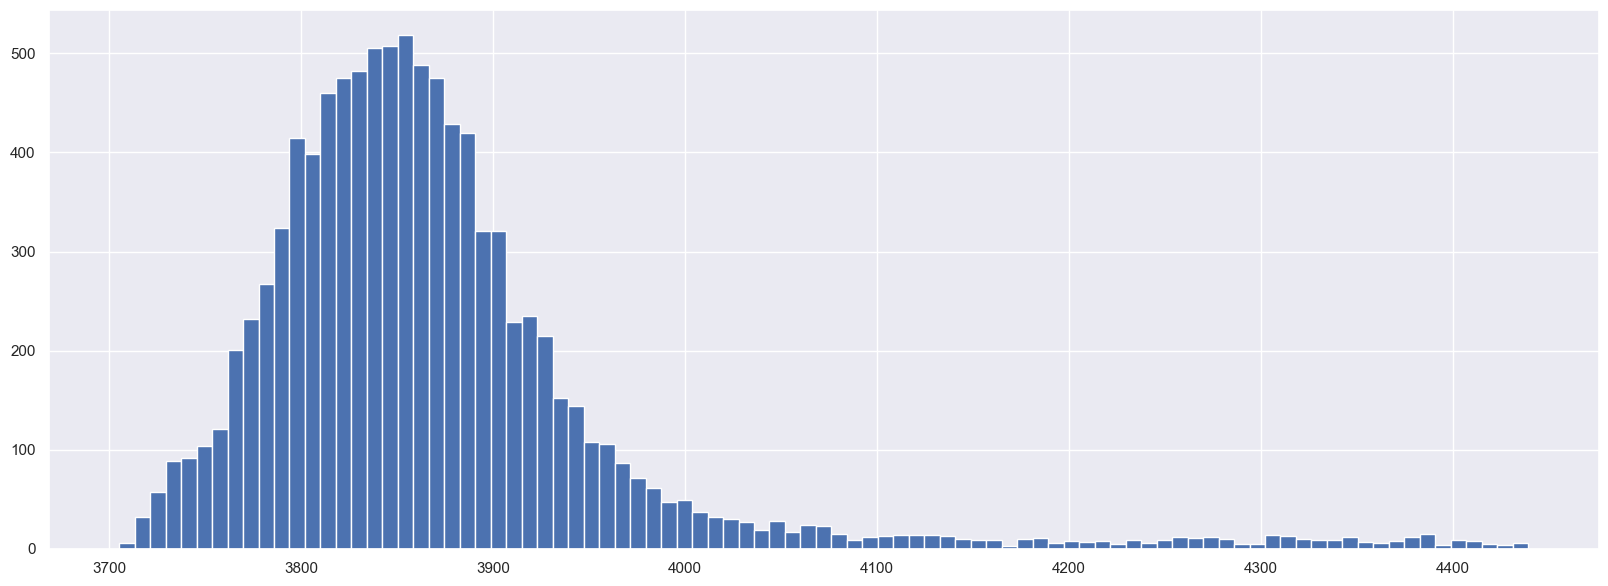

In [120]:
# Same matrix variability
time_logs_original = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_original,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data={
       i: {
           'matrix': np.linalg.inv(A),
           'det': np.linalg.det(np.linalg.inv(A))
       } for i in range(N_MAT)
    }
)
time_logs_original['elapsed_time_microsecs'].describe()

count    10000.000000
mean      3880.025510
std        364.605937
min       3726.458000
25%       3816.750000
50%       3838.583000
75%       3878.333000
max      28285.750000
Name: elapsed_time_microsecs, dtype: float64

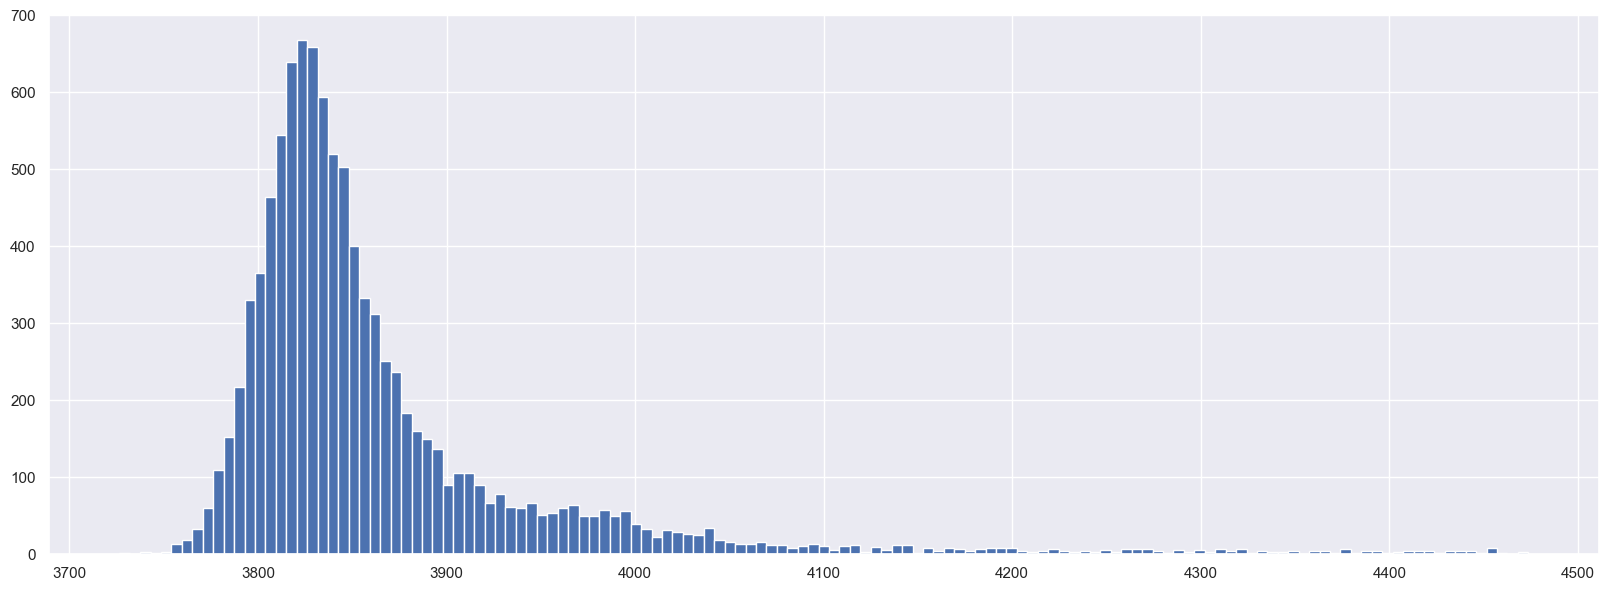

In [121]:
# Different matrix variability
time_logs_original = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_original,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data=samples_data,
)
time_logs_original['elapsed_time_microsecs'].describe()

In [122]:
time_logs_original.sort_values(
    by='elapsed_time_microsecs',
    ascending=False
).head(20).reset_index(drop=True)

,B,B_det,start_time,end_time,elapsed_time,elapsed_time_microsecs
0,"[[1.6412673677410612, 0.6862859170171921], [1....",-0.316626,40392582855958,40392611141708,28285750,28285.750
1,"[[-0.7901307735788428, -0.18199815260370808], ...",0.354216,40395939518083,40395963761000,24242917,24242.917
2,"[[-1.3374636679863638, -0.061962963371143064],...",0.460323,40386891564166,40386904347291,12783125,12783.125
3,"[[0.5839243994882217, 1.9362859902650713], [0....",-0.490403,40386882060625,40386890412875,8352250,8352.250
4,"[[-0.5306893883375945, 0.28728397873939465], [...",-0.531809,40386909338500,40386917535541,8197041,8197.041
5,"[[-0.021097624878277623, -1.9826615565750223],...",1.742058,40395964269583,40395971574541,7304958,7304.958
6,"[[-2.297266039124529, 0.6878270365138146], [1....",-2.738440,40369698925666,40369706124333,7198667,7198.667
7,"[[0.07509154048839295, -0.4488662775926125], [...",0.373047,40369764771708,40369771524875,6753167,6753.167
8,"[[0.08396228565582362, -0.26424299206938395], ...",0.121289,40369749143166,40369755727708,6584542,6584.542
9,"[[0.694784578436159, -0.32190282570260303], [-...",0.359853,40369742331916,40369748793833,6461917,6461.917


## 3.2. Função com list comprehension

In [123]:
def get_log_posterior_fn_list_comprehension(
    source_pdf_fn,
    prior_pdf_fn
):
    """
        This method returns a method for calculating log-posterior inside MCMC.
    """
    def __log_posterior_fn(
        x,
        B,
        source_pdf_fn,
        prior_pdf_fn
    ):
        NOBS=x.shape[-1]
        
        # Cálculo de posteriori para registros
        posteriori = NOBS*np.log(np.abs(np.linalg.det(B)))
        y=B@x
        posteriori += np.sum([
            np.log(source_pdf_fn(y[i,j])) for i,j in np.ndindex(x.shape)
        ])
        # for i, j in np.ndindex(x.shape):
        #     posteriori += np.log(source_pdf_fn(y[i,j]))
        posteriori += np.log(prior_pdf_fn(B))
    
        return posteriori

    return lambda x, B: __log_posterior_fn(
        x=x,
        B=B,
        source_pdf_fn=source_pdf_fn,
        prior_pdf_fn=prior_pdf_fn
    )

count    10000.000000
mean      3837.834087
std        294.230215
min       3686.459000
25%       3786.584000
50%       3816.209000
75%       3845.750000
max      24282.375000
Name: elapsed_time_microsecs, dtype: float64

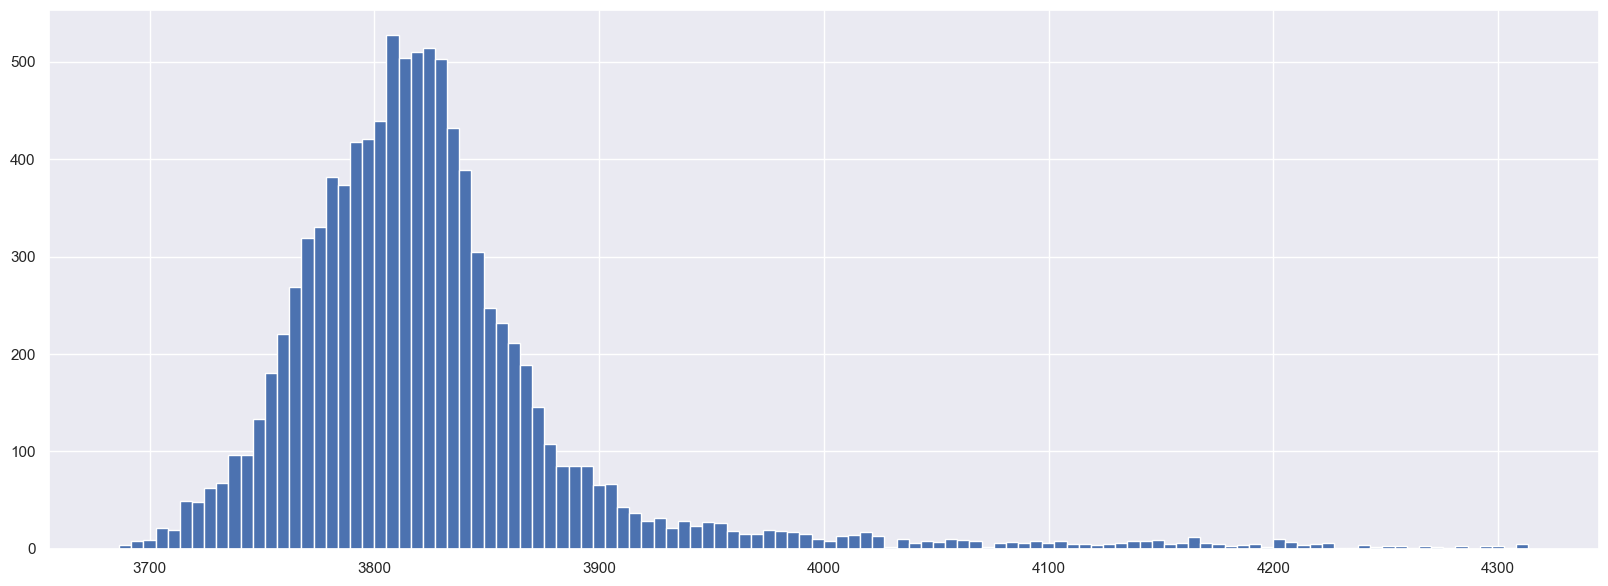

In [124]:
# Same matrix variability
time_logs_list_comp = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_list_comprehension,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data={
       i: {
           'matrix': np.linalg.inv(A),
           'det': np.linalg.det(np.linalg.inv(A))
       } for i in range(N_MAT)
    }
)
time_logs_list_comp['elapsed_time_microsecs'].describe()

count    10000.000000
mean      3819.919623
std        229.455574
min       3711.083000
25%       3765.083750
50%       3785.625000
75%       3826.020750
max      18062.750000
Name: elapsed_time_microsecs, dtype: float64

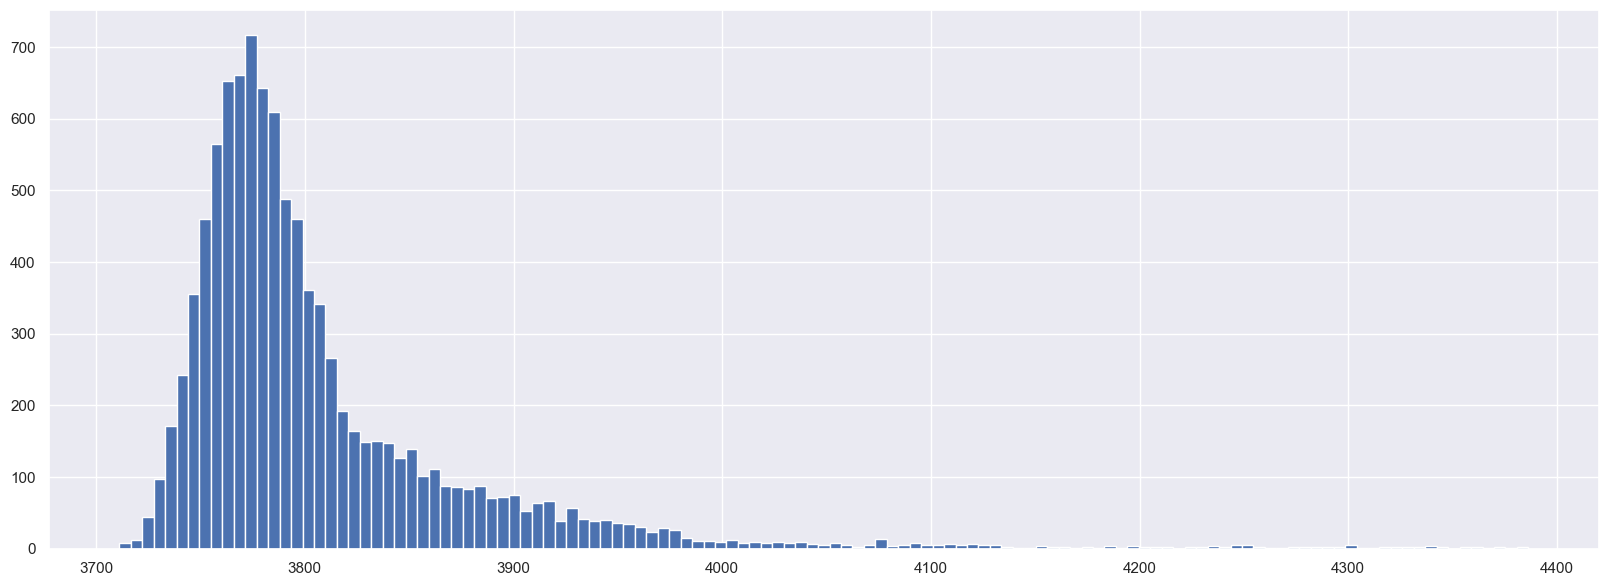

In [125]:
# Different matrix variability
time_logs_list_comp = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_list_comprehension,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data=samples_data,
)
time_logs_list_comp['elapsed_time_microsecs'].describe()

## 3.3. Função com list comprehension e log externo

In [126]:
def get_log_posterior_fn_list_comprehension_external_log(
    source_pdf_fn,
    prior_pdf_fn
):
    """
        This method returns a method for calculating log-posterior inside MCMC.
    """
    def __log_posterior_fn(
        x,
        B,
        source_pdf_fn,
        prior_pdf_fn
    ):
        NOBS=x.shape[-1]
        
        # Cálculo de posteriori para registros
        posteriori = NOBS*np.log(np.abs(np.linalg.det(B)))
        y=B@x
        iterator = np.ndindex(x.shape)
        posteriori += np.sum(np.log(
            np.array([
                source_pdf_fn(y[i,j]) for i,j in iterator
            ])
        ))
        posteriori += np.log(prior_pdf_fn(B))
    
        return posteriori

    return lambda x, B: __log_posterior_fn(
        x=x,
        B=B,
        source_pdf_fn=source_pdf_fn,
        prior_pdf_fn=prior_pdf_fn
    )

count    10000.000000
mean      3207.156538
std        268.898333
min       3068.000000
25%       3139.072500
50%       3171.062500
75%       3218.771000
max      20382.416000
Name: elapsed_time_microsecs, dtype: float64

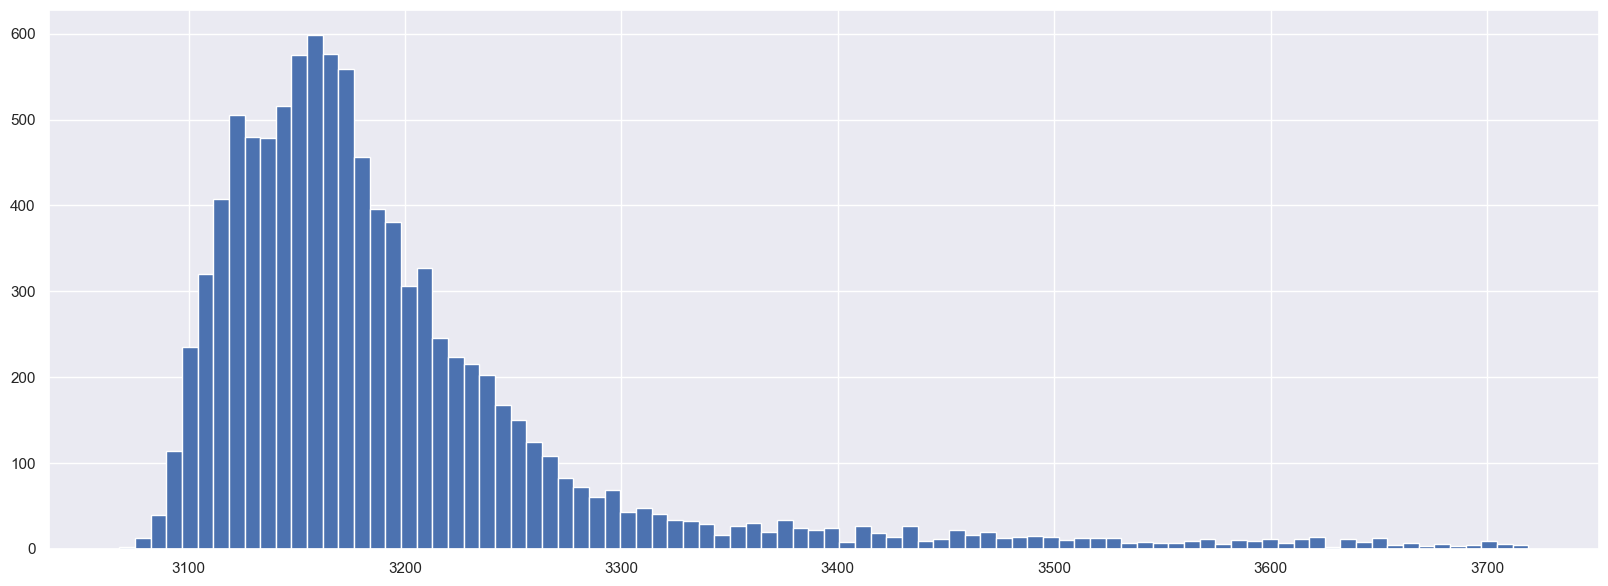

In [127]:
# Same matrix variability
time_logs_list_comp_ext_log = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_list_comprehension_external_log,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data={
       i: {
           'matrix': np.linalg.inv(A),
           'det': np.linalg.det(np.linalg.inv(A))
       } for i in range(N_MAT)
    }
)
time_logs_list_comp_ext_log['elapsed_time_microsecs'].describe()

count    10000.000000
mean      3278.024270
std        308.007888
min       3130.541000
25%       3220.625000
50%       3251.209000
75%       3293.458000
max      25653.542000
Name: elapsed_time_microsecs, dtype: float64

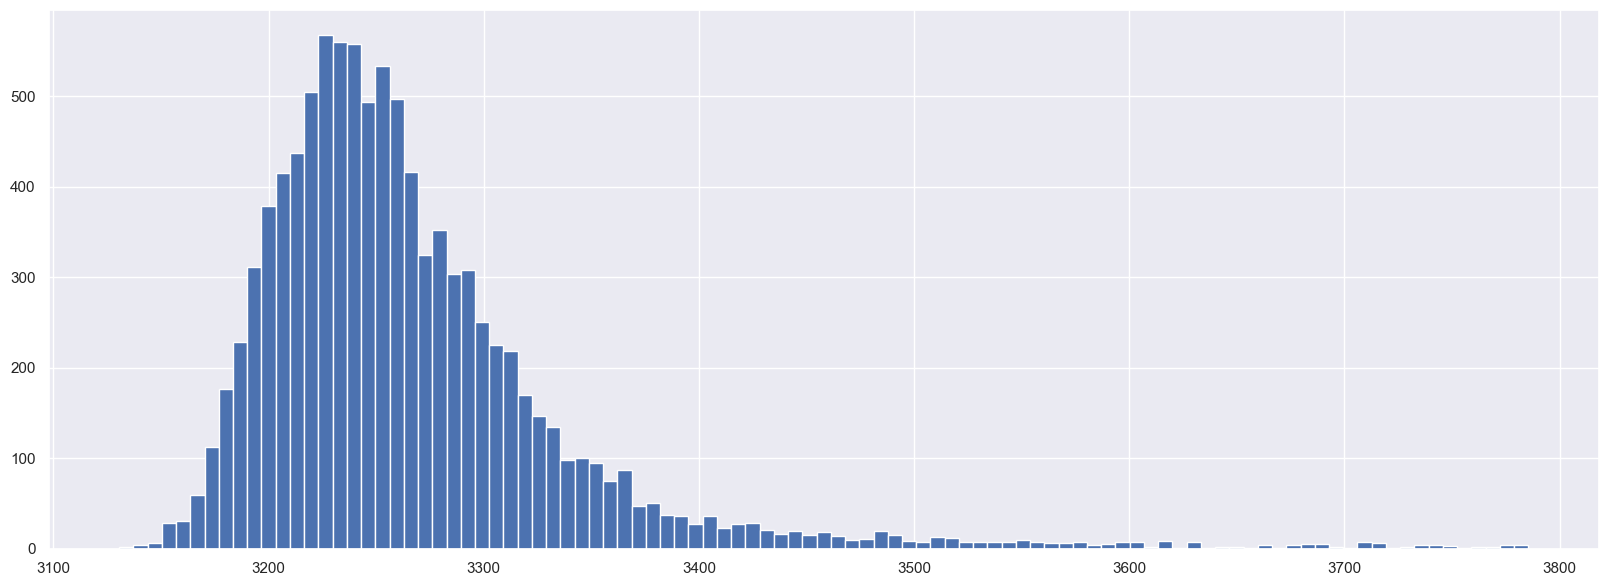

In [128]:
# Different matrix variability
time_logs_list_comp_ext_log = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_list_comprehension_external_log,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data=samples_data,
)
time_logs_list_comp_ext_log['elapsed_time_microsecs'].describe()

## 3.4. Função com list comprehension, log externo e somatório unico para calculo de posteriori

In [129]:
def get_log_posterior_fn_list_comprehension_external_log_one_sum(
    source_pdf_fn,
    prior_pdf_fn
):
    """
        This method returns a method for calculating log-posterior inside MCMC.
    """
    def __log_posterior_fn(
        x,
        B,
        source_pdf_fn,
        prior_pdf_fn
    ):
        NOBS=x.shape[-1]
        
        # Estimativa das fontes
        y=B@x

        # Iterador para calculo de posteriori
        iterator = np.ndindex(x.shape)

        # Cálculo de posteriori para registros
        return NOBS*np.log(np.abs(np.linalg.det(B))) + np.sum(np.log(
            np.array([
                source_pdf_fn(y[i,j]) for i,j in iterator
            ])
        )) + np.log(prior_pdf_fn(B))

    return lambda x, B: __log_posterior_fn(
        x=x,
        B=B,
        source_pdf_fn=source_pdf_fn,
        prior_pdf_fn=prior_pdf_fn
    )

count    10000.000000
mean      3184.632861
std        177.315704
min       3050.875000
25%       3136.166750
50%       3165.625000
75%       3199.875000
max      15377.625000
Name: elapsed_time_microsecs, dtype: float64

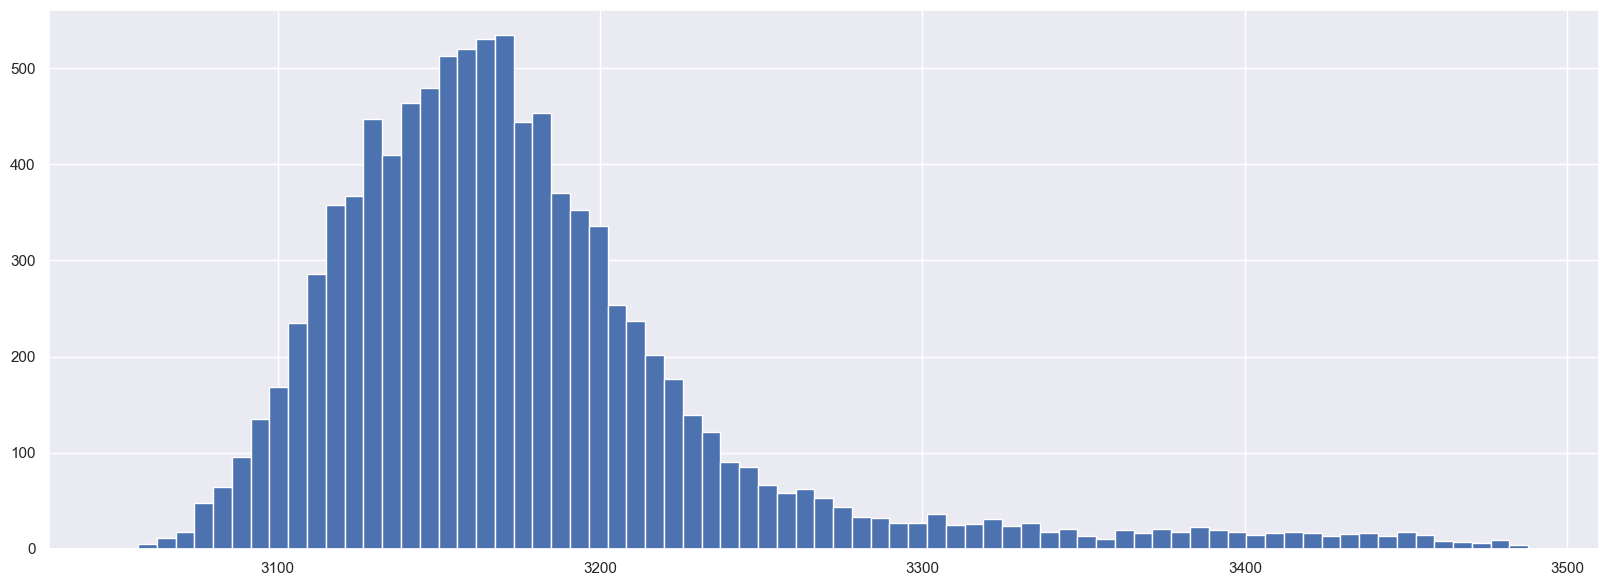

In [130]:
# Same matrix variability
time_logs_list_comp_ext_log_one_sum = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_list_comprehension_external_log_one_sum,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data={
       i: {
           'matrix': np.linalg.inv(A),
           'det': np.linalg.det(np.linalg.inv(A))
       } for i in range(N_MAT)
    }
)
time_logs_list_comp_ext_log_one_sum['elapsed_time_microsecs'].describe()

count    10000.000000
mean      3270.151752
std        536.474221
min       3085.584000
25%       3169.833750
50%       3203.854000
75%       3253.781250
max      26696.208000
Name: elapsed_time_microsecs, dtype: float64

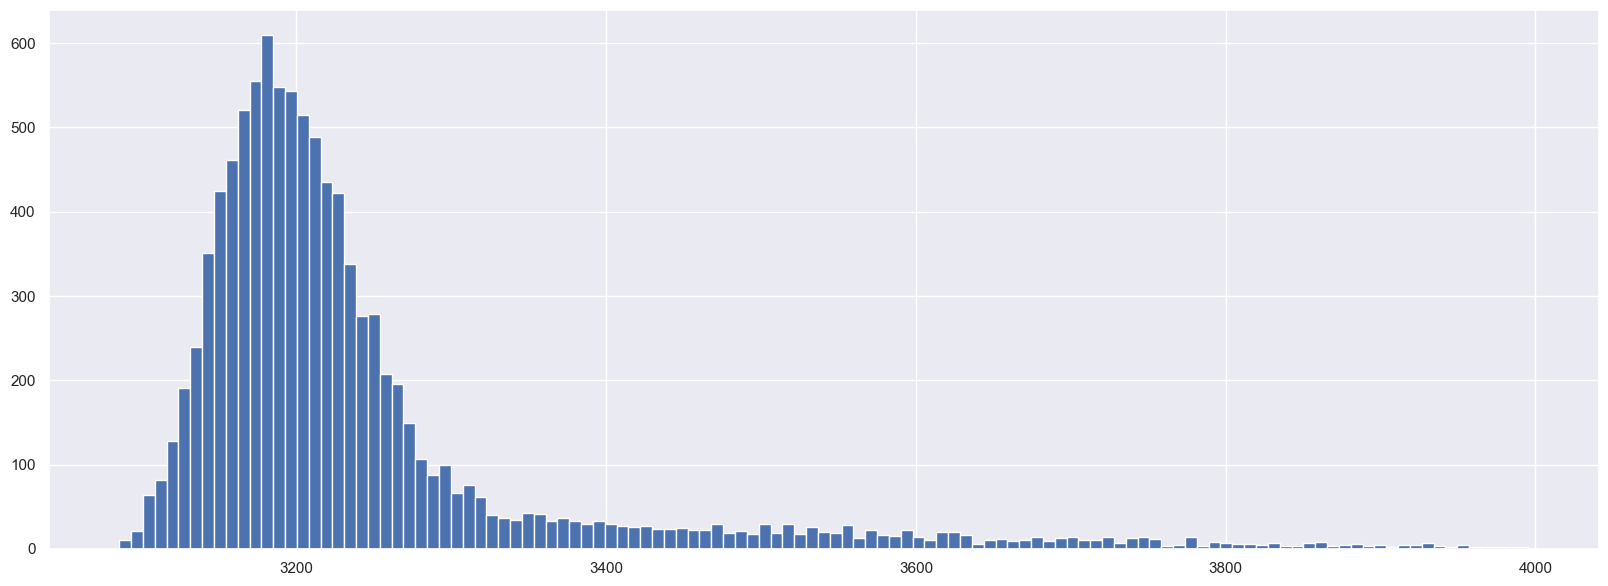

In [133]:
# Different matrix variability
time_logs_list_comp_ext_log_one_sum = log_posterior_times(
    get_log_posterior_fn=get_log_posterior_fn_list_comprehension_external_log_one_sum,
    X=X,
    source_pdf_fn=source_pdf.get(),
    prior_pdf_fn=prior.get(),
    samples_data=samples_data,
)
time_logs_list_comp_ext_log_one_sum['elapsed_time_microsecs'].describe()

# 4. Ganho cumulativo na log-posteriori com melhoria na source_pdf

In [ ]:
def compare_log_posteriori_times(
    X,
    get_log_posterior_fn_original,
    source_pdf_fn_original,
    get_log_posterior_fn_opt,
    source_pdf_fn_opt,
    prior_pdf_fn,
    samples_data,
):
    logs = pd.DataFrame()
    log_posterior_fn_original = get_log_posterior_fn_original(
        source_pdf_fn = source_pdf_fn_original,
        prior_pdf_fn = prior_pdf_fn
    )
    log_posterior_fn_opt = get_log_posterior_fn_opt(
        source_pdf_fn = source_pdf_fn_opt,
        prior_pdf_fn = prior_pdf_fn
    )
    for k, v in samples_data.items():
        B = v['matrix']
        start_original = time.perf_counter_ns()
        orig = log_posterior_fn_original(
            x=X,
            B=B
        )
        end_original = time.perf_counter_ns()
        opt = log_posterior_fn_opt(
            x=X,
            B=B
        )
        end_opt = time.perf_counter_ns()

        logs = pd.concat(
            [
                logs,
                pd.DataFrame(
                    index=[k],
                    data = {
                        'B': [B],
                        'B_det': v['det'],
                        'original_start_time': [start_original],
                        'original_end_time': [end_original],
                        'opt_end_time': [end_opt],
                        'original_elapsed_time': [end_original-start_original],
                        'opt_elapsed_time': [end_opt-end_original],
                        'opt_original_diff': [end_opt + start_original -2*end_original],
                        'original_log_posteriori': [orig],
                        'opt_log_posteriori': [opt]
                    }
                )
            ],
            axis=0
        )

    logs['original_elapsed_time_microsecs'] = logs['original_elapsed_time']/1000
    logs['opt_elapsed_time_microsecs'] = logs['opt_elapsed_time']/1000
    logs['opt_original_diff_microsecs'] = logs['opt_original_diff']/1000

    fig_diffs, axs_diffs = plt.subplots(
        nrows=2, ncols=1,
        figsize=(20,20)
    )

    # Figura com distribuições de tempos
    axs_diffs[0].hist(
        x=logs['opt_elapsed_time']
    )
    axs_diffs[0].hist(
        x=plot_df['opt_original_diff_microsecs'],
        bins='fd'
    )
    
    return logs

{0: {'matrix': array([[-0.24765838,  1.17839474],
         [ 0.22403607, -0.59930275]]),
  'det': np.float64(-0.11558057782700529)},
 1: {'matrix': array([[ 0.00316206, -0.05618693],
         [ 1.5160738 ,  0.22802342]]),
  'det': np.float64(0.08590455792906385)},
 2: {'matrix': array([[-2.325938  ,  1.3867558 ],
         [ 0.69328861, -1.68448445]]),
  'det': np.float64(2.9565843851423326)},
 3: {'matrix': array([[-0.87734451,  1.78418974],
         [-2.22162835, -1.07102215]]),
  'det': np.float64(4.903461916902129)},
 4: {'matrix': array([[ 0.17622703, -0.75473178],
         [ 0.98404253,  1.10294391]]),
  'det': np.float64(0.9370566996020787)},
 5: {'matrix': array([[ 1.1331185 ,  0.60582754],
         [-1.11468833,  0.11684874]]),
  'det': np.float64(0.8077123611638809)},
 6: {'matrix': array([[-1.18219892, -3.49600107],
         [-0.40707269,  0.14133934]]),
  'det': np.float64(-1.5902177667852144)},
 7: {'matrix': array([[ 1.19391134,  0.12507994],
         [-0.0875814 ,  1.3232

,original_elapsed_time_microsecs,opt_elapsed_time_microsecs,opt_original_diff_microsecs
count,100.000000,100.000000,100.000000
mean,3956.158740,1470.904980,-2485.253760
std,280.635412,38.882321,263.969418
min,3813.584000,1423.500000,-4312.791000
25%,3860.771250,1447.822500,-2468.656750
50%,3893.312500,1458.854500,-2433.084000
75%,3934.260250,1477.572500,-2402.916750
max,5875.958000,1665.792000,-2286.250000


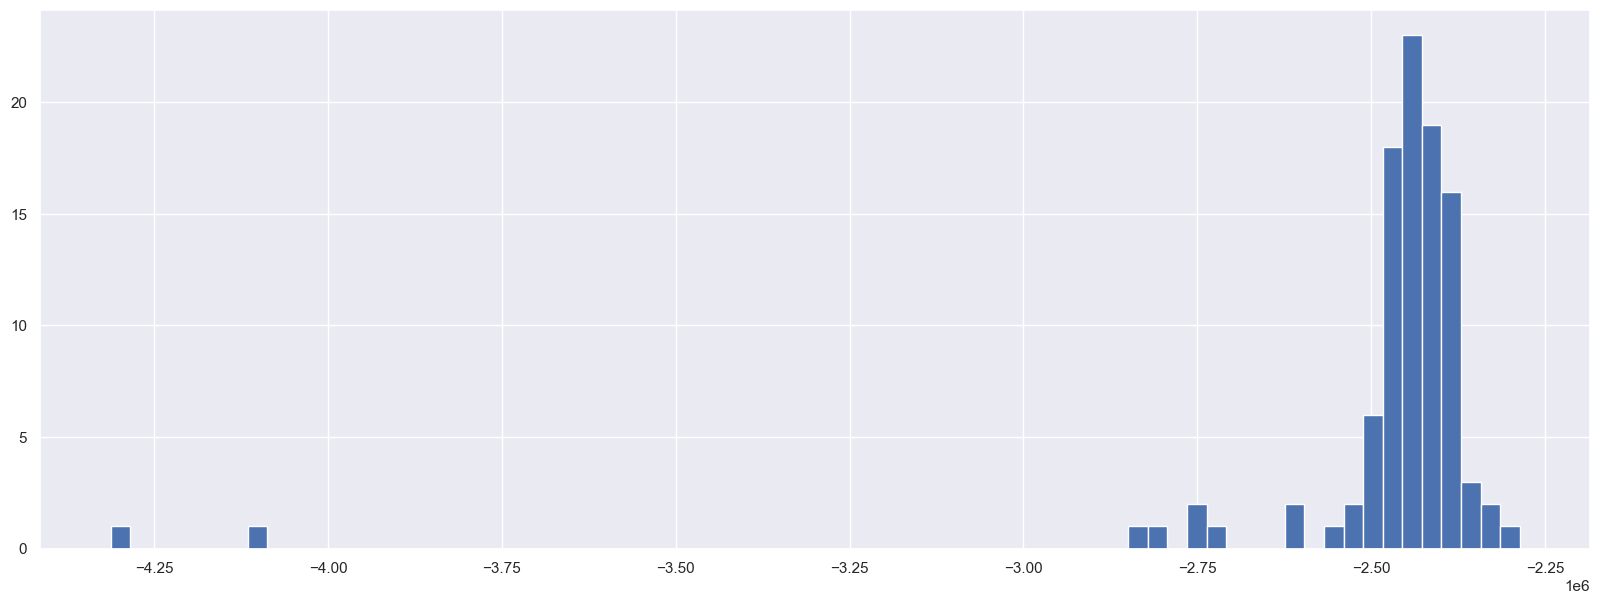

In [148]:
logs = compare_log_posteriori_times(
    X=X,
    get_log_posterior_fn_original=get_log_posterior_fn_original,
    source_pdf_fn_original=source_pdf.get(),
    get_log_posterior_fn_opt=get_log_posterior_fn_list_comprehension_external_log_one_sum,
    source_pdf_fn_opt=get_logistic_math(),
    prior_pdf_fn=prior.get(),
    samples_data={k: v for k, v in samples_data.items() if k<100}
)
logs[[
    'original_elapsed_time_microsecs',
    'opt_elapsed_time_microsecs',
    'opt_original_diff_microsecs'
]].describe()

In [144]:
logs[[
    'original_elapsed_time_microsecs',
    'opt_elapsed_time_microsecs',
    'opt_original_diff_microsecs'
]].describe()

,original_elapsed_time_microsecs,opt_elapsed_time_microsecs,opt_original_diff_microsecs
count,10000.000000,10000.000000,10000.000000
mean,3868.704960,1454.830551,-2413.874410
std,134.674646,109.244700,137.533216
min,3769.500000,1408.166000,-13863.958000
25%,3841.917000,1438.209000,-2431.916000
50%,3861.500000,1449.104500,-2411.646000
75%,3884.208000,1462.427250,-2392.251000
max,15597.708000,11727.458000,3470.041000
